In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

In [19]:
data = pd.read_csv('C:/Users/ak587/Downloads/Supermarket Grocery Sales/Supermart Grocery Sales - Retail Analytics Dataset.csv')

In [21]:
data.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State
0,OD1,Harish,Oil & Masala,Masalas,Vellore,11-08-2017,North,1254,0.12,401.28,Tamil Nadu
1,OD2,Sudha,Beverages,Health Drinks,Krishnagiri,11-08-2017,South,749,0.18,149.80,Tamil Nadu
2,OD3,Hussain,Food Grains,Atta & Flour,Perambalur,06-12-2017,West,2360,0.21,165.20,Tamil Nadu
3,OD4,Jackson,Fruits & Veggies,Fresh Vegetables,Dharmapuri,10-11-2016,South,896,0.25,89.60,Tamil Nadu
4,OD5,Ridhesh,Food Grains,Organic Staples,Ooty,10-11-2016,South,2355,0.26,918.45,Tamil Nadu


In [23]:
data.isnull().sum()

Order ID         0
Customer Name    0
Category         0
Sub Category     0
City             0
Order Date       0
Region           0
Sales            0
Discount         0
Profit           0
State            0
dtype: int64

In [25]:
data.dropna(inplace = True)

In [27]:
data.drop_duplicates(inplace = True)

In [37]:
data['Order Date'] = pd.to_datetime(data['Order Date'], format='mixed', dayfirst=False)

In [41]:
data['Order Day'] = data['Order Date'].dt.day
data['Order Month'] = data['Order Date'].dt.month
data['Order Year'] = data['Order Date'].dt.year

In [43]:
le = LabelEncoder()

In [49]:
data['Category'] = le.fit_transform(data['Category'])
data['Sub Category'] = le.fit_transform(data['Sub Category'])
data['City'] = le.fit_transform(data['City'])
data['Region'] = le.fit_transform(data['Region'])
data['State'] = le.fit_transform(data['State'])

In [51]:
data.head()

,Order ID,Customer Name,Category,Sub Category,City,Order Date,Region,Sales,Discount,Profit,State,Order Day,Order Month,Order Year
0,OD1,Harish,5,14,21,2017-11-08,2,1254,0.12,401.28,0,8,11,2017
1,OD2,Sudha,1,13,8,2017-11-08,3,749,0.18,149.80,0,8,11,2017
2,OD3,Hussain,3,0,13,2017-06-12,4,2360,0.21,165.20,0,12,6,2017
3,OD4,Jackson,4,12,4,2016-10-11,3,896,0.25,89.60,0,11,10,2016
4,OD5,Ridhesh,3,18,12,2016-10-11,3,2355,0.26,918.45,0,11,10,2016


C:\Users\ak587\AppData\Local\Temp\ipykernel_12788\2194088829.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x = 'Category',


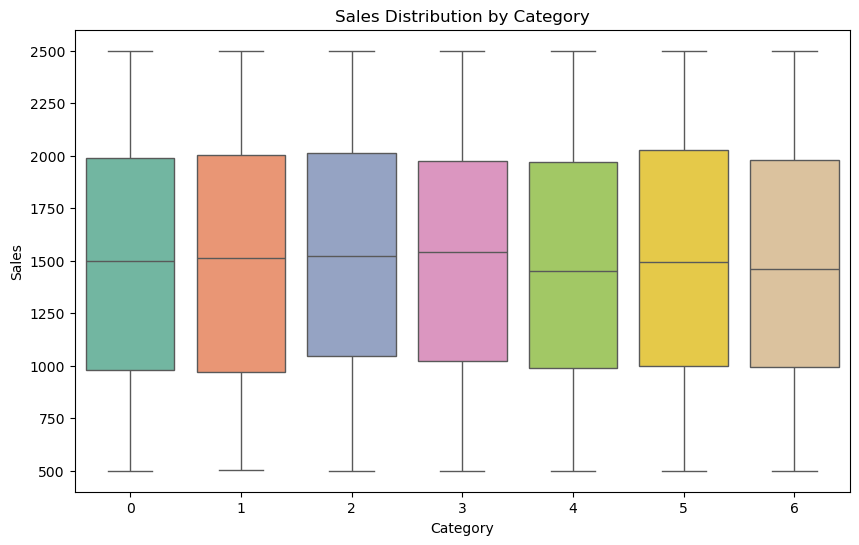

In [53]:
plt.figure(figsize = (10, 6))
sns.boxplot(x = 'Category',
           y = 'Sales',
           data = data,
           palette = 'Set2')
plt.title('Sales Distribution by Category')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()

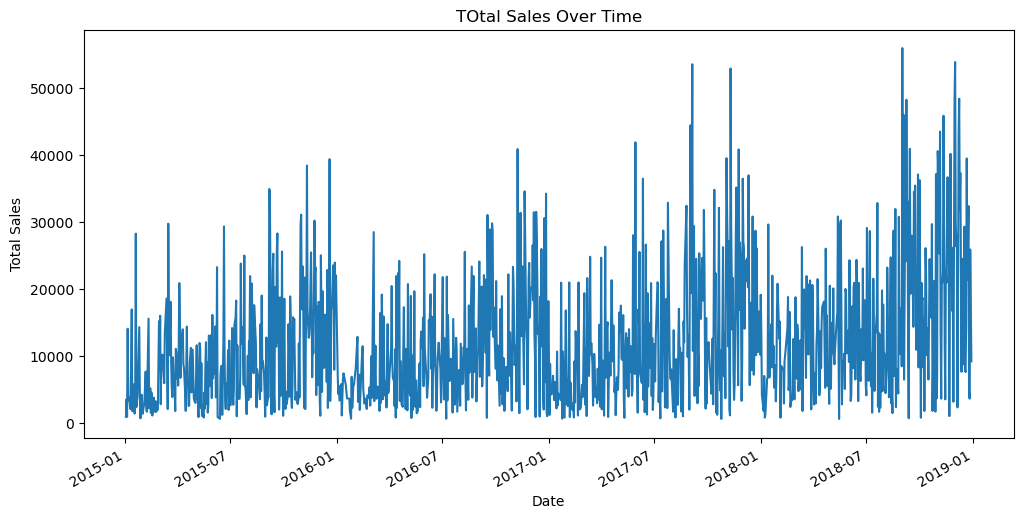

In [55]:
plt.figure(figsize= (12, 6))
data.groupby('Order Date')['Sales'].sum().plot()
plt.title('TOtal Sales Over Time')
plt.xlabel('Date')
plt.ylabel('Total Sales')
plt.show()

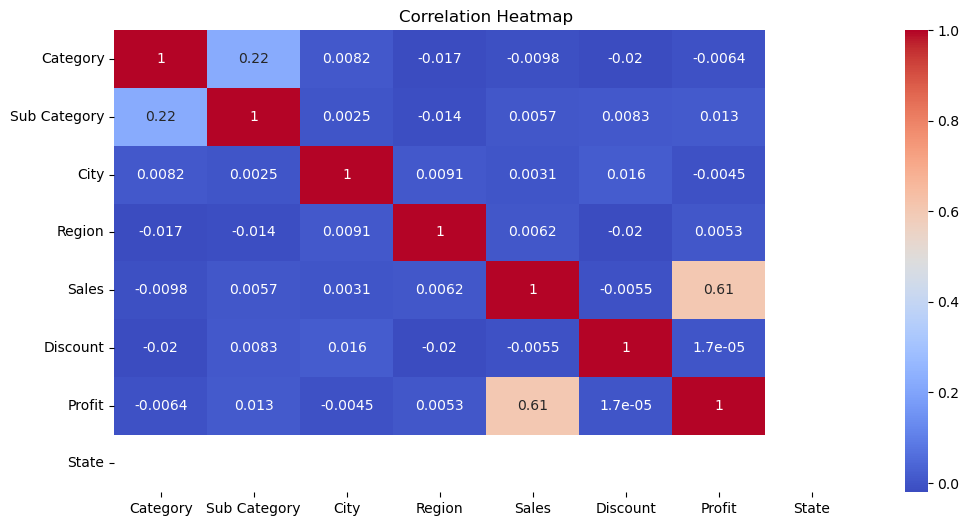

In [67]:
plt.figure(figsize = (12, 6))
exclude_columns = ['Order ID']
numeric_data = data.drop(columns=exclude_columns, errors='ignore').select_dtypes(include=['int64', 'float64'])
corr_matrix = numeric_data.corr()
sns.heatmap(corr_matrix,
           annot = True,
           cmap = 'coolwarm')
plt.title('Correlation Heatmap')
plt.show()

In [71]:
features = data.drop(columns = ['Order ID', 'Customer Name', 'Order Date', 'Sales'])
target = data['Sales']

In [75]:
x_train, x_test, y_train, y_test = train_test_split(features, 
                                                    target, 
                                                    test_size = 0.2, 
                                                    random_state = 42)

In [77]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [79]:
model = LinearRegression()

In [81]:
model.fit(x_train, y_train)

LinearRegression()

In [85]:
y_pred = model.predict(x_test)

In [90]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Mean Squared Error: {mse:.2f}')
print(f'R-squared: {r2:.2f}')

Mean Squared Error: 212954.08
R-squared: 0.35


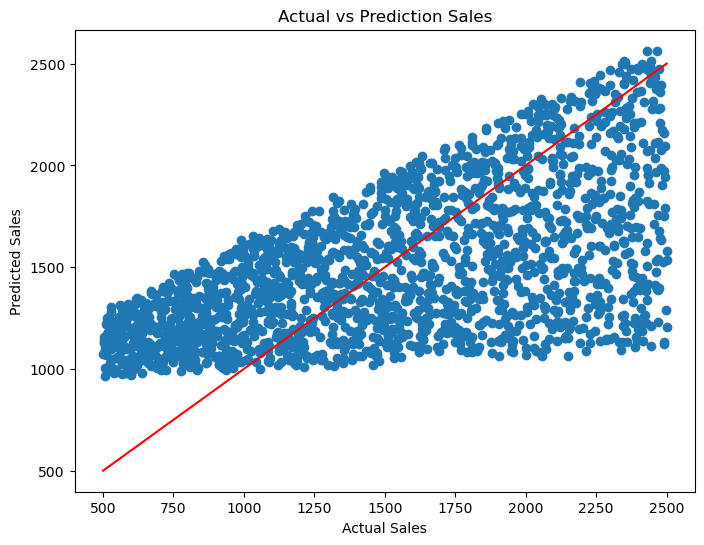

In [92]:
plt.figure(figsize = (8, 6))
plt.scatter(y_test, y_pred)
plt.plot([min(y_test), max(y_test)], 
         [min(y_test), max(y_test)],
         color = 'red')
plt.title('Actual vs Prediction Sales')
plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.show()

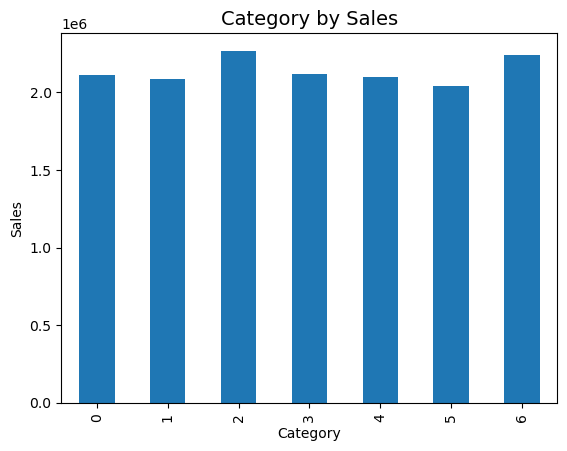

In [100]:
Sales_category=data.groupby("Category")["Sales"].sum()
Sales_category.plot(kind='bar')
plt.title('Category by Sales', fontsize = 14)
plt.xlabel('Category')
plt.ylabel('Sales')
plt.show()